# Task 07 — Unsupervised Learning & Customer Segmentation
K-Means, DBSCAN, and hierarchical clustering on the Mall Customer dataset, with silhouette/Davies-Bouldin evaluation, PCA visualization, and business-facing cluster profiles.

In [1]:
import sys
sys.path.append('src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_mall_customers
from preprocessing import clean, scale_features, FEATURES
from modeling import (kmeans_sweep, fit_kmeans, fit_hierarchical, fit_dbscan,
                       evaluate, pca_2d, profile_clusters, RANDOM_SEED)

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)

## 1. Load & Clean Data

In [2]:
raw = load_mall_customers("data/Mall_Customers.csv")
df = clean(raw)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,70,22,18
1,2,Male,59,22,81
2,3,Female,34,66,24
3,4,Female,69,83,21
4,5,Male,44,87,76


In [3]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,44.415000,54.855000,49.115000
std,57.879185,NaN,16.166308,28.383306,29.115983
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,30.000000,27.000000,23.000000
50%,100.500000,NaN,44.000000,55.000000,46.000000
75%,150.250000,NaN,60.000000,82.000000,79.000000


## 2. Exploratory Data Analysis

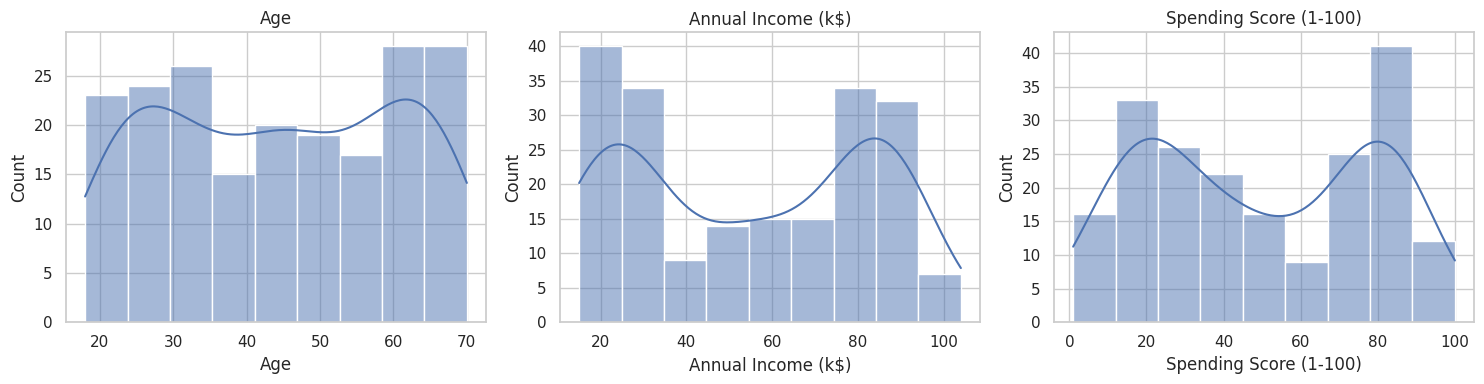

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, FEATURES):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/01_feature_distributions.png", dpi=150)
plt.show()

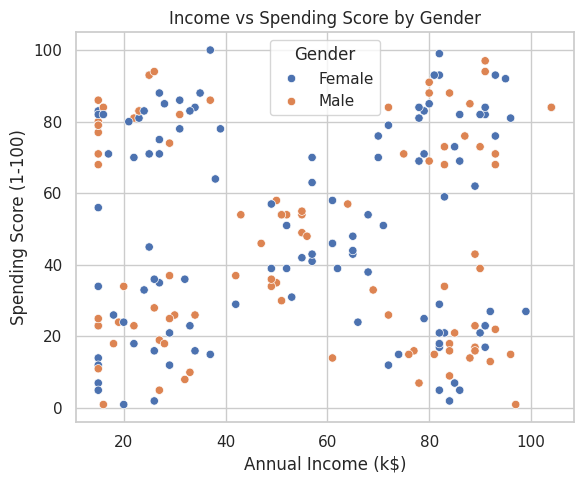

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", ax=ax)
ax.set_title("Income vs Spending Score by Gender")
plt.tight_layout()
plt.savefig("figures/02_income_vs_spending.png", dpi=150)
plt.show()

## 3. Preprocessing
Features are standardized (mean 0, std 1) because K-Means/DBSCAN/hierarchical clustering rely on Euclidean distance, and Age/Income/Spending Score sit on very different scales — without scaling, Income would dominate the distance metric.

In [6]:
X_scaled, scaler = scale_features(df)
X_scaled[:5]

array([[ 1.58658384, -1.1604514 , -1.07133873],
       [ 0.90444891, -1.1604514 ,  1.09785105],
       [-0.64585775,  0.39364574, -0.86474923],
       [ 1.52457157,  0.99409237, -0.96804398],
       [-0.02573509,  1.13537393,  0.92569313]])

## 4. Model Selection — Elbow Method & Silhouette Sweep (K-Means)

In [7]:
sweep = kmeans_sweep(X_scaled, k_range=range(2, 11))
sweep

,k,inertia,silhouette
0,2,430.850479,0.270966
1,3,336.252437,0.273272
2,4,247.795521,0.344416
3,5,199.393468,0.363423
4,6,164.064580,0.366226
5,7,137.989331,0.377326
6,8,113.295953,0.394465
7,9,94.255086,0.404701
8,10,79.487755,0.416188


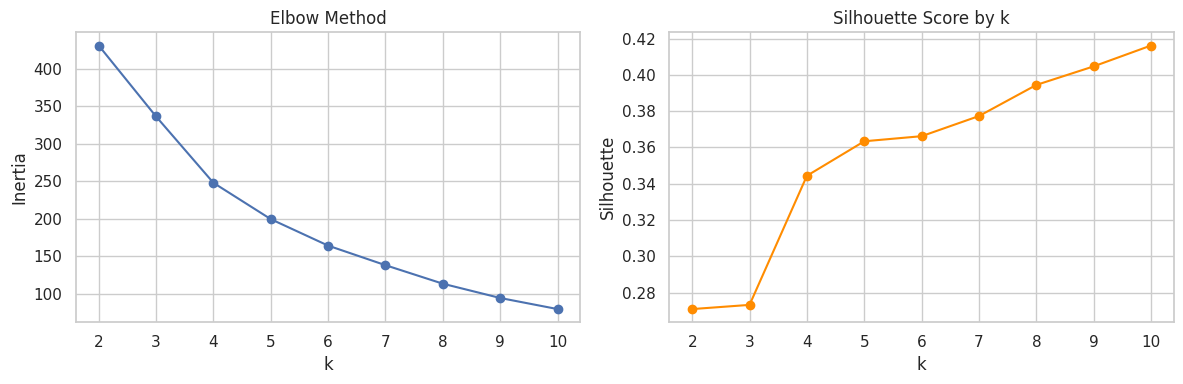

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep["k"], sweep["inertia"], marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("figures/03_elbow_and_silhouette.png", dpi=150)
plt.show()

Based on the elbow bend and peak silhouette score, we select **k=5**, which also matches the business ask of 4-6 personas.

In [9]:
K = 5
km_model = fit_kmeans(X_scaled, K)
df["kmeans_cluster"] = km_model.labels_
evaluate(X_scaled, km_model.labels_)

{'silhouette': 0.363423174506589,
 'davies_bouldin': 0.9264745844996201,
 'n_clusters': 5}

## 5. Compare Algorithms

In [10]:
hier_model = fit_hierarchical(X_scaled, K)
df["hier_cluster"] = hier_model.labels_

db_model = fit_dbscan(X_scaled, eps=0.6, min_samples=5)
df["dbscan_cluster"] = db_model.labels_

comparison = pd.DataFrame([
    {"algorithm": "K-Means", **evaluate(X_scaled, km_model.labels_)},
    {"algorithm": "Hierarchical (Ward)", **evaluate(X_scaled, hier_model.labels_)},
    {"algorithm": "DBSCAN", **evaluate(X_scaled, db_model.labels_)},
])
comparison

,algorithm,silhouette,davies_bouldin,n_clusters
0,K-Means,0.363423,0.926475,5
1,Hierarchical (Ward),0.307558,1.019465,5
2,DBSCAN,0.110177,1.033761,5


## 6. Baseline Comparison
Simple baseline: split customers into 5 equal-width bins on Spending Score alone (a naive single-feature segmentation a business analyst might do without ML).

In [11]:
baseline_labels = pd.cut(df["Spending Score (1-100)"], bins=K, labels=False).to_numpy()
baseline_score = evaluate(X_scaled, baseline_labels)
print("Baseline (spending-score bins):", baseline_score)
print("K-Means:                       ", evaluate(X_scaled, km_model.labels_))

Baseline (spending-score bins): {'silhouette': 0.026782057120804007, 'davies_bouldin': 4.507504820495698, 'n_clusters': 5}
K-Means:                        {'silhouette': 0.363423174506589, 'davies_bouldin': 0.9264745844996201, 'n_clusters': 5}


## 7. PCA Visualization

Explained variance: PC1=36.7%, PC2=33.2%


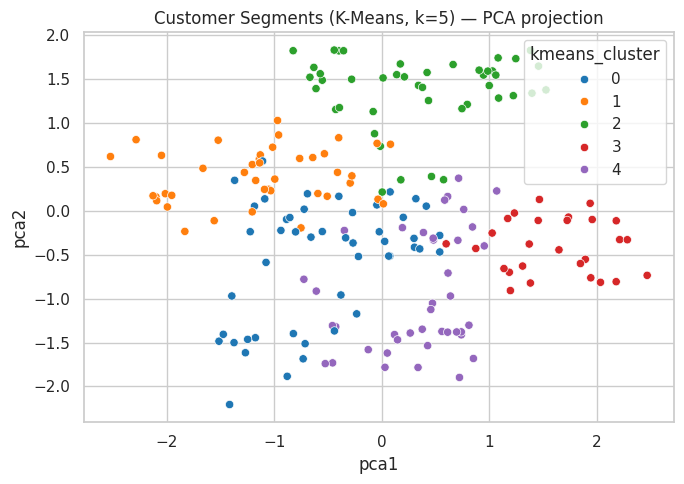

In [12]:
coords, var_ratio = pca_2d(X_scaled)
df["pca1"], df["pca2"] = coords[:, 0], coords[:, 1]
print(f"Explained variance: PC1={var_ratio[0]:.1%}, PC2={var_ratio[1]:.1%}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="kmeans_cluster", palette="tab10", ax=ax)
ax.set_title(f"Customer Segments (K-Means, k={K}) — PCA projection")
plt.tight_layout()
plt.savefig("figures/04_pca_clusters.png", dpi=150)
plt.show()

## 8. Cluster Profiling — Business Personas

In [13]:
profile = profile_clusters(df, km_model.labels_, FEATURES)
profile

,Age,Annual Income (k$),Spending Score (1-100),size,pct_of_total
cluster,,,,,
0,27.1,55.8,31.6,48,24.0
1,42.4,85.0,80.0,41,20.5
2,46.3,25.8,77.8,44,22.0
3,57.3,24.7,17.5,27,13.5
4,56.5,75.2,28.2,40,20.0


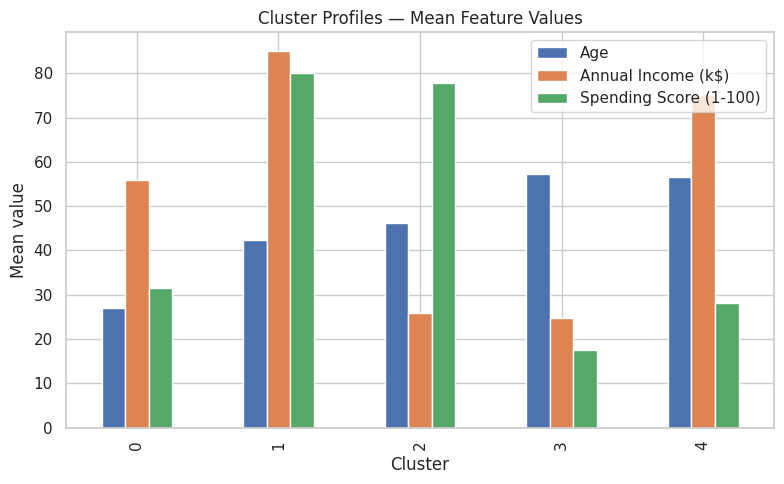

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
profile[FEATURES].plot(kind="bar", ax=ax)
ax.set_title("Cluster Profiles — Mean Feature Values")
ax.set_xlabel("Cluster"); ax.set_ylabel("Mean value")
plt.tight_layout()
plt.savefig("figures/05_cluster_profiles.png", dpi=150)
plt.show()

### Persona summary
- **Cluster read-out:** each row above pairs a persona (e.g. "high income / high spend", "low income / high spend") with its size, to feed directly into `reports/REPORT.md` and campaign targeting.

## 9. Limitations
- Small dataset (200 rows) proxies a 200K-customer base — cluster boundaries may not generalize.
- Only 3 numeric features used; richer behavioral data (purchase history, recency/frequency) would likely sharpen segments.
- DBSCAN is sensitive to `eps`/`min_samples`; results shown use one setting, not a full grid search.
- Clusters were validated internally (silhouette/DB); no ground-truth labels exist to check external validity.